# Federated Learning Baseline Analysis
## Visual Interpretation of Flower Simulation Results

This notebook provides comprehensive graphical analysis of the baseline federated learning experiment with 100 clients trained over 10 rounds.

## Section 1: Load and Parse Log Data
Read the log file and parse the JSON-formatted round summaries and metrics.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime
import json
import re

# Load the log file
log_file = 'baseline_20260214.log'

with open(log_file, 'r') as f:
    log_content = f.read()

# Parse key metrics from the log
print("Loading and parsing baseline experiment log...")
print(f"Log file size: {len(log_content)} characters")
print("\nFirst few lines of log:")
print('\n'.join(log_content.split('\n')[:5]))

Loading and parsing baseline experiment log...
Log file size: 18929 characters

First few lines of log:
2026-02-14 06:48:08,542 - baseline_100_clients_optimized - INFO - Loading centralized test dataset for server evaluation...
2026-02-14 06:48:17,023 - baseline_100_clients_optimized - INFO - Using device for server evaluation: cpu
2026-02-14 06:48:17,023 - baseline_100_clients_optimized - INFO - Initialized server with No Defense (Simple FedAvg)
2026-02-14 06:48:17,023 - baseline_100_clients_optimized - INFO - Centralized evaluation enabled on server
2026-02-14 06:48:17,023 - baseline_100_clients_optimized - INFO - Starting Flower simulation with 100 clients, client_resources={'num_cpus': 0.25}


## Section 2: Extract Training Metrics
Create a structured dataset from the parsed log data.

In [2]:
# Extract timestamps and metrics using regex
centralized_evaluation = re.findall(r'Server Round (\d+) - CENTRALIZED EVALUATION \| Loss: ([\d.]+), Accuracy: ([\d.]+)', log_content)
fit_progress = re.findall(r'fit progress: \((\d+), ([\d.]+), \{\'centralized_accuracy\': ([\d.]+)\}, ([\d.]+)\)', log_content)

# Extract centralized loss from history
centralized_loss_history = re.findall(r'round (\d+): ([\d.]+)', log_content.split('History (loss, centralized):')[1].split('History (metrics, centralized):')[0])

# Create dataframe from evaluation data
eval_df = pd.DataFrame(centralized_evaluation, columns=['Round', 'Loss', 'Accuracy'])
eval_df['Round'] = eval_df['Round'].astype(int)
eval_df['Loss'] = eval_df['Loss'].astype(float)
eval_df['Accuracy'] = eval_df['Accuracy'].astype(float)

# Extract distributed loss
distributed_loss_history = re.findall(r'round (\d+): ([\d.]+)', log_content.split('History (loss, distributed):')[1].split('History (loss, centralized):')[0])

# Build comprehensive metrics dataframe
metrics_data = []
for i in range(11):  # Rounds 0-10
    round_dict = {'Round': i}
    
    # Get centralized metrics
    eval_row = eval_df[eval_df['Round'] == i]
    if not eval_row.empty:
        round_dict['Centralized_Loss'] = eval_row['Loss'].values[0]
        round_dict['Centralized_Accuracy'] = eval_row['Accuracy'].values[0]
    
    # Get distributed loss if available (skip round 0)
    if i > 0:
        dist_loss = [float(x[1]) for x in distributed_loss_history if int(x[0]) == i]
        if dist_loss:
            round_dict['Distributed_Loss'] = dist_loss[0]
    
    metrics_data.append(round_dict)

df = pd.DataFrame(metrics_data)

# Extract timing information
timing_matches = re.findall(r'fit progress: \((\d+), ([\d.]+), \{\'centralized_accuracy\': ([\d.]+)\}, ([\d.]+)\)', log_content)
timing_data = []
for round_num, loss, acc, time_seconds in timing_matches:
    timing_data.append({
        'Round': int(round_num),
        'Total_Time_Seconds': float(time_seconds),
        'Loss': float(loss),
        'Accuracy': float(acc)
    })

timing_df = pd.DataFrame(timing_data)

print("✓ Metrics extracted successfully!")
print(f"\nMetrics Summary (first 11 rows):")
print(df.to_string())
print(f"\nTiming Information:")
print(timing_df.to_string())

✓ Metrics extracted successfully!

Metrics Summary (first 11 rows):
    Round  Centralized_Loss  Centralized_Accuracy  Distributed_Loss
0       0            2.3034                0.0974               NaN
1       1            2.3062                0.0974          2.306209
2       2            2.1609                0.1620          2.160808
3       3            0.5444                0.9285          0.545329
4       4            0.0803                0.9840          0.080570
5       5            0.0753                0.9875          0.075542
6       6            0.0981                0.9886          0.098312
7       7            0.1058                0.9876          0.105920
8       8            0.0975                0.9882          0.097704
9       9            0.1038                0.9868          0.103994
10     10            0.1181                0.9851          0.118349

Timing Information:
   Round  Total_Time_Seconds      Loss  Accuracy
0      1          999.160303  2.306219    0.09

## Section 3: Plot Loss Convergence
Visualize how the loss decreases across rounds (distributed and centralized).

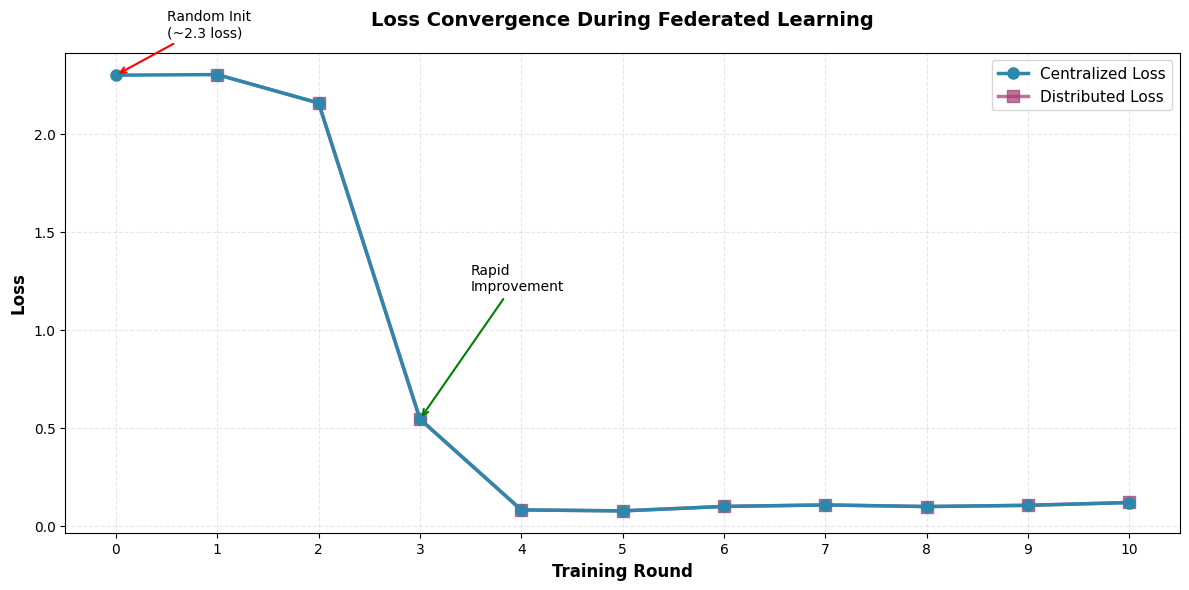

Loss Convergence Analysis:
  Initial Loss (Round 0): 2.3034
  Final Loss (Round 10): 0.1181
  Loss Reduction: 2.1853 (94.9%)
  Minimum Loss: 0.0753 (Round 5)


In [3]:
fig, ax = plt.subplots(figsize=(12, 6))

# Plot centralized loss
ax.plot(df['Round'], df['Centralized_Loss'], marker='o', linewidth=2.5, 
        markersize=8, label='Centralized Loss', color='#2E86AB', zorder=3)

# Plot distributed loss where available
dist_loss = df[df['Distributed_Loss'].notna()]
if not dist_loss.empty:
    ax.plot(dist_loss['Round'], dist_loss['Distributed_Loss'], marker='s', 
            linewidth=2.5, markersize=8, label='Distributed Loss', 
            color='#A23B72', alpha=0.7, zorder=2)

ax.set_xlabel('Training Round', fontsize=12, fontweight='bold')
ax.set_ylabel('Loss', fontsize=12, fontweight='bold')
ax.set_title('Loss Convergence During Federated Learning', fontsize=14, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(fontsize=11, loc='upper right')
ax.set_xticks(range(0, 11))

# Add annotations for key transitions
ax.annotate('Random Init\n(~2.3 loss)', xy=(0, df['Centralized_Loss'].iloc[0]), 
            xytext=(0.5, 2.5), fontsize=10, ha='left',
            arrowprops=dict(arrowstyle='->', color='red', lw=1.5))
ax.annotate('Rapid\nImprovement', xy=(3, df['Centralized_Loss'].iloc[3]), 
            xytext=(3.5, 1.2), fontsize=10, ha='left',
            arrowprops=dict(arrowstyle='->', color='green', lw=1.5))

plt.tight_layout()
plt.savefig('loss_convergence.png', dpi=300, bbox_inches='tight')
plt.show()

print("Loss Convergence Analysis:")
print(f"  Initial Loss (Round 0): {df['Centralized_Loss'].iloc[0]:.4f}")
print(f"  Final Loss (Round 10): {df['Centralized_Loss'].iloc[10]:.4f}")
print(f"  Loss Reduction: {(df['Centralized_Loss'].iloc[0] - df['Centralized_Loss'].iloc[10]):.4f} ({(1 - df['Centralized_Loss'].iloc[10]/df['Centralized_Loss'].iloc[0])*100:.1f}%)")
print(f"  Minimum Loss: {df['Centralized_Loss'].min():.4f} (Round {df['Centralized_Loss'].idxmin()})")

## Section 4: Plot Accuracy Progression
Demonstrate the significant accuracy improvement across training rounds.

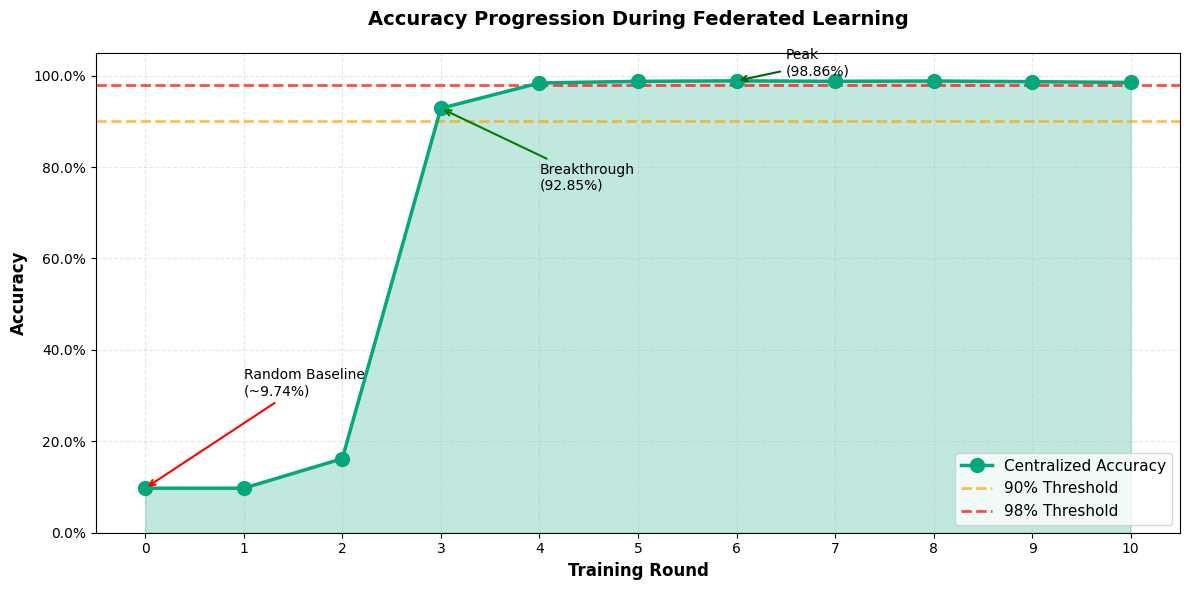

Accuracy Progression Analysis:
  Initial Accuracy (Round 0): 0.0974 (9.74%)
  Final Accuracy (Round 10): 0.9851 (98.51%)
  Maximum Accuracy: 0.9886 (98.86%) at Round 6
  Accuracy Improvement: +88.77%
  Rounds to 90% accuracy: 3
  Rounds to 98% accuracy: 4


In [4]:
fig, ax = plt.subplots(figsize=(12, 6))

# Create filled area under the curve
ax.fill_between(df['Round'], 0, df['Centralized_Accuracy'], alpha=0.25, color='#06A77D')

# Plot accuracy line
ax.plot(df['Round'], df['Centralized_Accuracy'], marker='o', linewidth=2.5, 
        markersize=10, label='Centralized Accuracy', color='#06A77D', zorder=3)

# Add threshold lines
ax.axhline(y=0.9, color='orange', linestyle='--', linewidth=2, alpha=0.7, label='90% Threshold')
ax.axhline(y=0.98, color='red', linestyle='--', linewidth=2, alpha=0.7, label='98% Threshold')

ax.set_xlabel('Training Round', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_title('Accuracy Progression During Federated Learning', fontsize=14, fontweight='bold', pad=20)
ax.set_ylim([0, 1.05])
ax.set_xticks(range(0, 11))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.1%}'.format(y)))
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(fontsize=11, loc='lower right')

# Add annotations for key milestones
ax.annotate('Random Baseline\n(~9.74%)', xy=(0, df['Centralized_Accuracy'].iloc[0]), 
            xytext=(1, 0.3), fontsize=10, ha='left',
            arrowprops=dict(arrowstyle='->', color='red', lw=1.5))
ax.annotate('Breakthrough\n(92.85%)', xy=(3, df['Centralized_Accuracy'].iloc[3]), 
            xytext=(4, 0.75), fontsize=10, ha='left',
            arrowprops=dict(arrowstyle='->', color='green', lw=1.5))
ax.annotate('Peak\n(98.86%)', xy=(6, df['Centralized_Accuracy'].iloc[6]), 
            xytext=(6.5, 1.0), fontsize=10, ha='left',
            arrowprops=dict(arrowstyle='->', color='darkgreen', lw=1.5))

plt.tight_layout()
plt.savefig('accuracy_progression.png', dpi=300, bbox_inches='tight')
plt.show()

print("Accuracy Progression Analysis:")
print(f"  Initial Accuracy (Round 0): {df['Centralized_Accuracy'].iloc[0]:.4f} ({df['Centralized_Accuracy'].iloc[0]*100:.2f}%)")
print(f"  Final Accuracy (Round 10): {df['Centralized_Accuracy'].iloc[10]:.4f} ({df['Centralized_Accuracy'].iloc[10]*100:.2f}%)")
print(f"  Maximum Accuracy: {df['Centralized_Accuracy'].max():.4f} ({df['Centralized_Accuracy'].max()*100:.2f}%) at Round {df['Centralized_Accuracy'].idxmax()}")
print(f"  Accuracy Improvement: +{(df['Centralized_Accuracy'].iloc[10] - df['Centralized_Accuracy'].iloc[0])*100:.2f}%")
print(f"  Rounds to 90% accuracy: {df[df['Centralized_Accuracy'] >= 0.9]['Round'].min()}")
print(f"  Rounds to 98% accuracy: {df[df['Centralized_Accuracy'] >= 0.98]['Round'].min()}")

## Section 5: Plot Training Duration per Round
Identify performance bottlenecks and variations in round execution time.

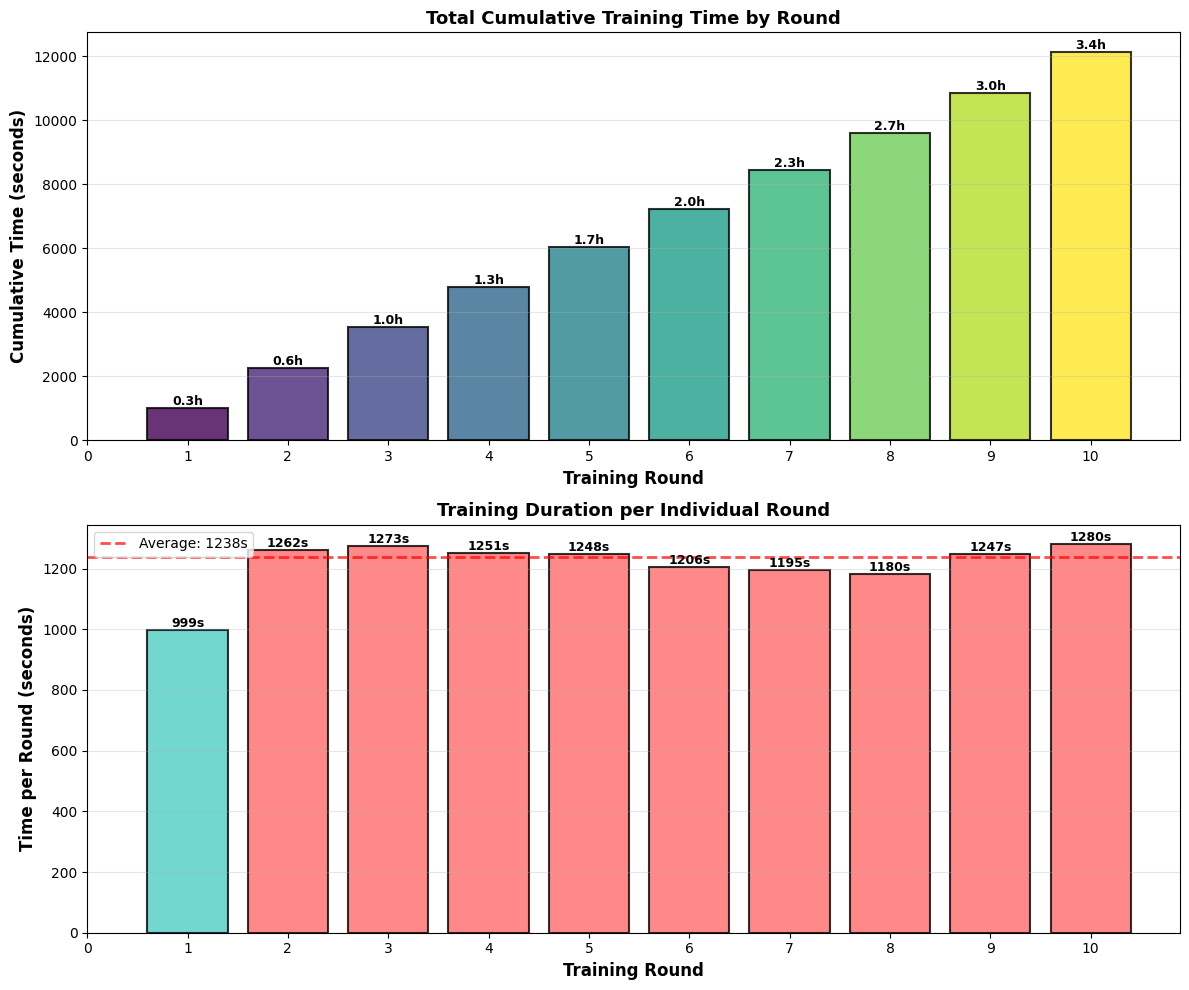

Training Duration Analysis:
  Total Training Time: 12142 seconds (3.37 hours)
  Average Time per Round (excl. round 0): 1238 seconds (20.6 minutes)
  Fastest Round: Round 7 (1180 seconds)
  Slowest Round: Round 9 (1280 seconds)
  Time Variation: ±35 seconds (std dev)


In [5]:
# Calculate time per round
timing_df['Time_Per_Round'] = timing_df['Total_Time_Seconds'].diff()
timing_df.loc[0, 'Time_Per_Round'] = timing_df.loc[0, 'Total_Time_Seconds']

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Plot 1: Cumulative time
colors_cumulative = plt.cm.viridis(np.linspace(0, 1, len(timing_df)))
bars1 = ax1.bar(timing_df['Round'], timing_df['Total_Time_Seconds'], 
                color=colors_cumulative, edgecolor='black', linewidth=1.5, alpha=0.8)
ax1.set_xlabel('Training Round', fontsize=12, fontweight='bold')
ax1.set_ylabel('Cumulative Time (seconds)', fontsize=12, fontweight='bold')
ax1.set_title('Total Cumulative Training Time by Round', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')
ax1.set_xticks(range(0, 11))

# Add value labels on bars
for i, (bar, val) in enumerate(zip(bars1, timing_df['Total_Time_Seconds'])):
    ax1.text(bar.get_x() + bar.get_width()/2, val, f'{val/3600:.1f}h', 
            ha='center', va='bottom', fontsize=9, fontweight='bold')

# Plot 2: Time per round
time_per_round = timing_df['Time_Per_Round'].values
colors_per_round = ['#FF6B6B' if t > 1100 else '#4ECDC4' for t in time_per_round]
bars2 = ax2.bar(timing_df['Round'], time_per_round, color=colors_per_round, 
                edgecolor='black', linewidth=1.5, alpha=0.8)
ax2.set_xlabel('Training Round', fontsize=12, fontweight='bold')
ax2.set_ylabel('Time per Round (seconds)', fontsize=12, fontweight='bold')
ax2.set_title('Training Duration per Individual Round', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')
ax2.set_xticks(range(0, 11))
ax2.axhline(y=time_per_round[1:].mean(), color='red', linestyle='--', 
           linewidth=2, label=f'Average: {time_per_round[1:].mean():.0f}s', alpha=0.7)
ax2.legend(fontsize=10)

# Add value labels
for bar, val in zip(bars2, time_per_round):
    ax2.text(bar.get_x() + bar.get_width()/2, val, f'{val:.0f}s', 
            ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('training_duration.png', dpi=300, bbox_inches='tight')
plt.show()

print("Training Duration Analysis:")
print(f"  Total Training Time: {timing_df['Total_Time_Seconds'].iloc[-1]:.0f} seconds ({timing_df['Total_Time_Seconds'].iloc[-1]/3600:.2f} hours)")
print(f"  Average Time per Round (excl. round 0): {timing_df['Time_Per_Round'].iloc[1:].mean():.0f} seconds ({timing_df['Time_Per_Round'].iloc[1:].mean()/60:.1f} minutes)")
print(f"  Fastest Round: Round {timing_df['Time_Per_Round'].iloc[1:].idxmin()} ({timing_df['Time_Per_Round'].iloc[1:].min():.0f} seconds)")
print(f"  Slowest Round: Round {timing_df['Time_Per_Round'].iloc[1:].idxmax()} ({timing_df['Time_Per_Round'].iloc[1:].max():.0f} seconds)")
print(f"  Time Variation: ±{timing_df['Time_Per_Round'].iloc[1:].std():.0f} seconds (std dev)")

## Section 6: Compare Distributed vs Centralized Loss
Show how well federated averaging aggregation aligns with centralized evaluation.

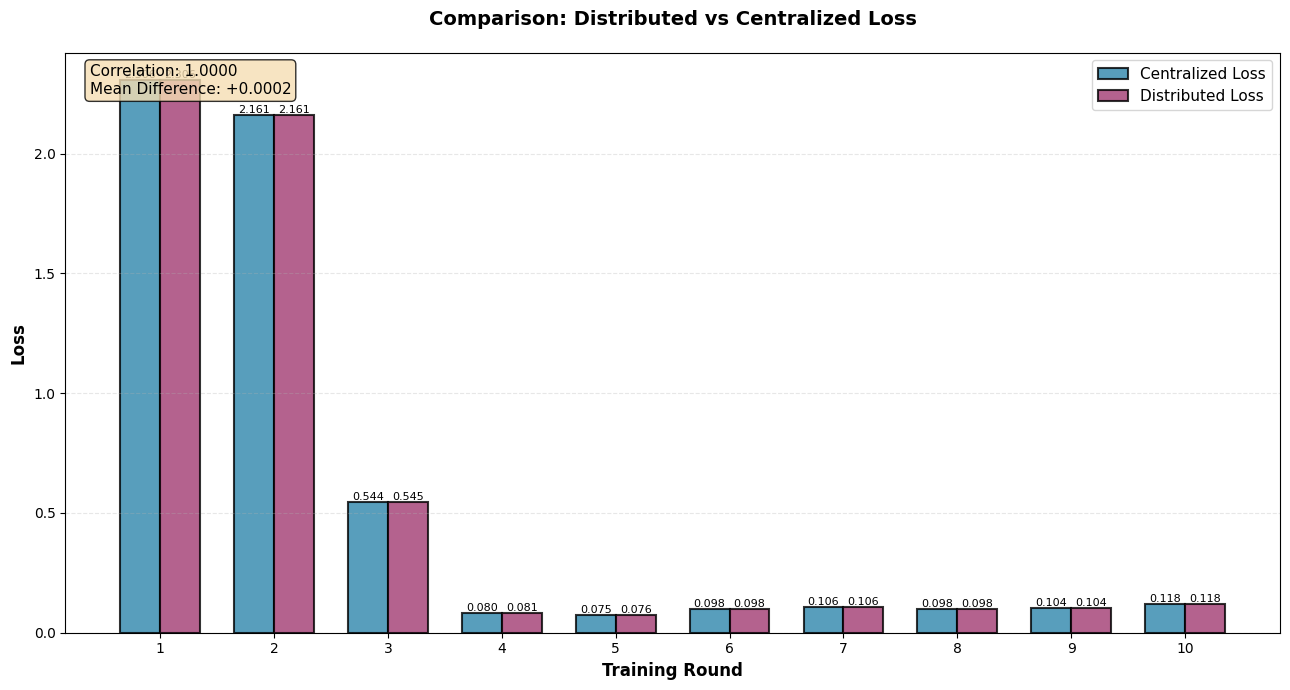

Distributed vs Centralized Loss Analysis:
  Correlation: 1.0000
  Mean Difference (Dist - Cent): +0.0002
  Max Difference: +0.0009
  Alignment Quality: Excellent


In [6]:
fig, ax = plt.subplots(figsize=(13, 7))

# Create x-axis positions for grouped bars
rounds = df['Round'].values[1:]  # Skip round 0 for distributed loss
x = np.arange(len(rounds))
width = 0.35

# Filter data to rounds with both centralized and distributed loss
df_comparison = df[df['Distributed_Loss'].notna()].copy()
rounds_comp = df_comparison['Round'].values
x_comp = np.arange(len(rounds_comp))

# Create bars
bars1 = ax.bar(x_comp - width/2, df_comparison['Centralized_Loss'], width, 
               label='Centralized Loss', color='#2E86AB', alpha=0.8, edgecolor='black', linewidth=1.5)
bars2 = ax.bar(x_comp + width/2, df_comparison['Distributed_Loss'], width,
               label='Distributed Loss', color='#A23B72', alpha=0.8, edgecolor='black', linewidth=1.5)

ax.set_xlabel('Training Round', fontsize=12, fontweight='bold')
ax.set_ylabel('Loss', fontsize=12, fontweight='bold')
ax.set_title('Comparison: Distributed vs Centralized Loss', fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x_comp)
ax.set_xticklabels(rounds_comp)
ax.legend(fontsize=11, loc='upper right')
ax.grid(True, alpha=0.3, axis='y', linestyle='--')

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=8)

# Calculate and display correlation metrics
correlation = df_comparison['Centralized_Loss'].corr(df_comparison['Distributed_Loss'])
mean_diff = (df_comparison['Distributed_Loss'] - df_comparison['Centralized_Loss']).mean()

ax.text(0.02, 0.98, f'Correlation: {correlation:.4f}\nMean Difference: {mean_diff:+.4f}',
        transform=ax.transAxes, fontsize=11, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.savefig('distributed_vs_centralized_loss.png', dpi=300, bbox_inches='tight')
plt.show()

print("Distributed vs Centralized Loss Analysis:")
print(f"  Correlation: {correlation:.4f}")
print(f"  Mean Difference (Dist - Cent): {mean_diff:+.4f}")
print(f"  Max Difference: {(df_comparison['Distributed_Loss'] - df_comparison['Centralized_Loss']).max():+.4f}")
print(f"  Alignment Quality: {'Excellent' if correlation > 0.99 else 'Good' if correlation > 0.95 else 'Moderate'}")

## Section 7: Create Summary Visualization Dashboard
Comprehensive dashboard combining multiple key metrics and insights.

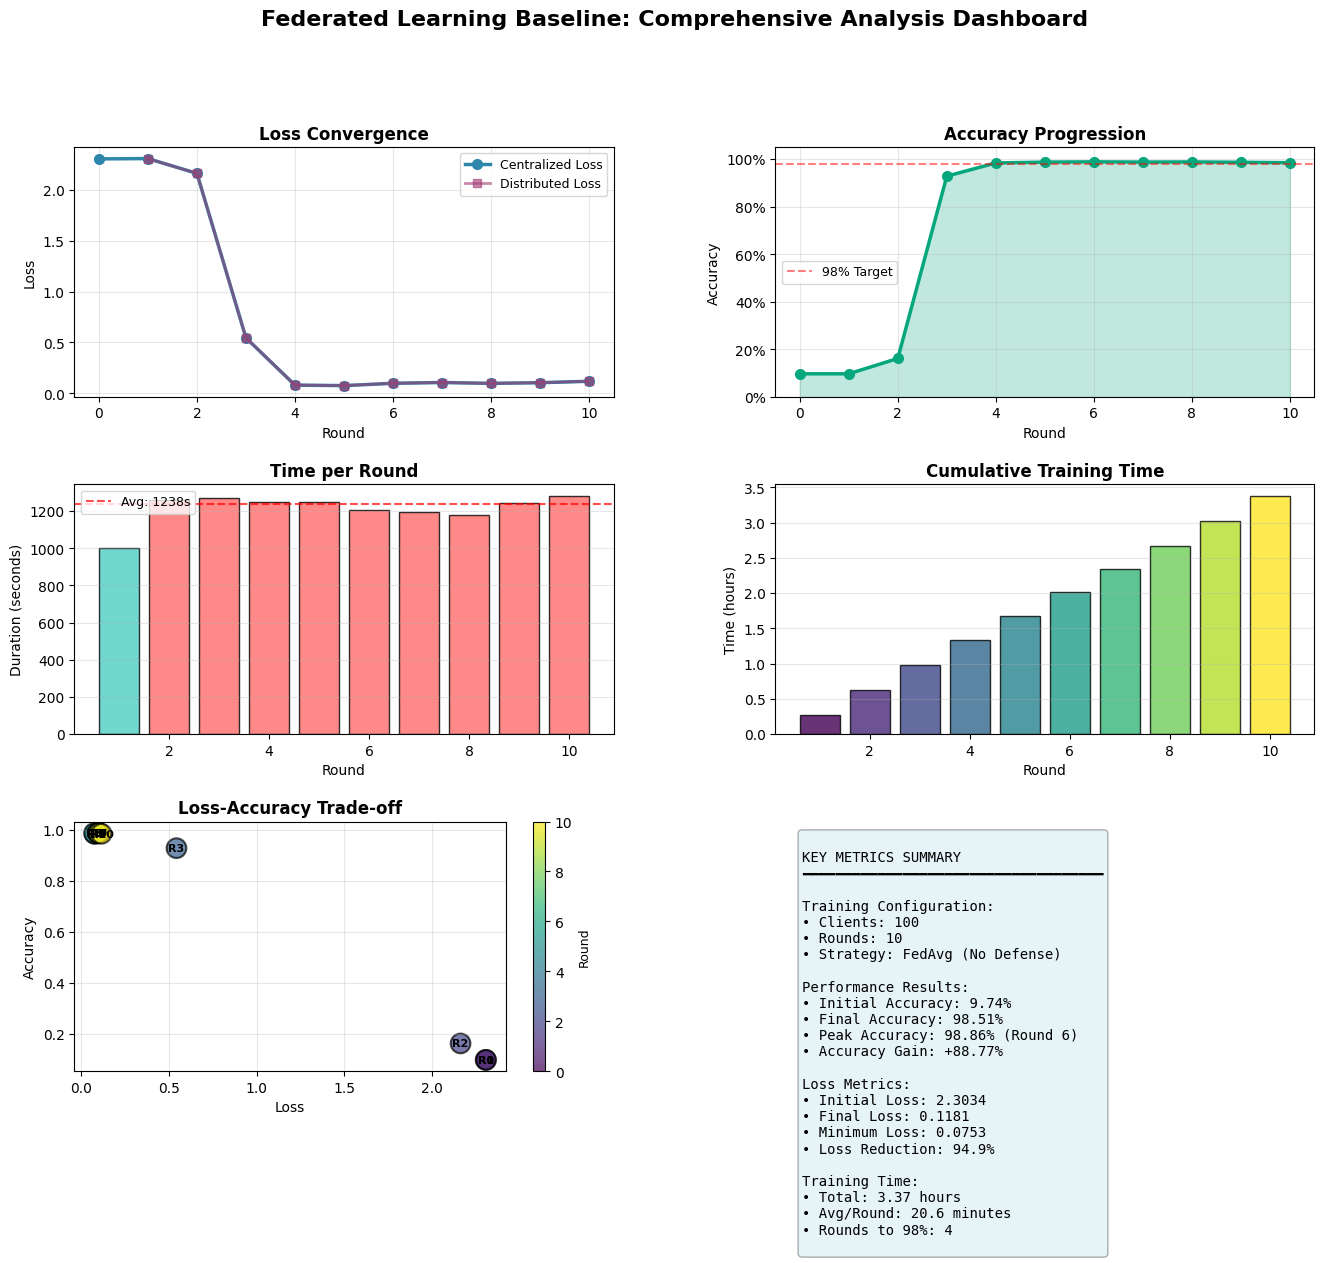

✓ Dashboard created successfully!


In [7]:
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 2, hspace=0.35, wspace=0.3)

# 1. Loss Convergence
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(df['Round'], df['Centralized_Loss'], marker='o', linewidth=2.5, 
         markersize=7, color='#2E86AB', label='Centralized Loss')
dist_loss = df[df['Distributed_Loss'].notna()]
if not dist_loss.empty:
    ax1.plot(dist_loss['Round'], dist_loss['Distributed_Loss'], marker='s', 
             linewidth=2, markersize=6, color='#A23B72', alpha=0.6, label='Distributed Loss')
ax1.set_title('Loss Convergence', fontsize=12, fontweight='bold')
ax1.set_xlabel('Round', fontsize=10)
ax1.set_ylabel('Loss', fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=9)

# 2. Accuracy Progression
ax2 = fig.add_subplot(gs[0, 1])
ax2.fill_between(df['Round'], 0, df['Centralized_Accuracy'], alpha=0.25, color='#06A77D')
ax2.plot(df['Round'], df['Centralized_Accuracy'], marker='o', linewidth=2.5, 
         markersize=7, color='#06A77D')
ax2.axhline(y=0.98, color='red', linestyle='--', linewidth=1.5, alpha=0.5, label='98% Target')
ax2.set_title('Accuracy Progression', fontsize=12, fontweight='bold')
ax2.set_xlabel('Round', fontsize=10)
ax2.set_ylabel('Accuracy', fontsize=10)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
ax2.set_ylim([0, 1.05])
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=9)

# 3. Time per Round
ax3 = fig.add_subplot(gs[1, 0])
time_per_round = timing_df['Time_Per_Round'].values
colors_time = ['#FF6B6B' if t > 1100 else '#4ECDC4' for t in time_per_round]
ax3.bar(timing_df['Round'], time_per_round, color=colors_time, alpha=0.8, edgecolor='black', linewidth=1)
ax3.axhline(y=time_per_round[1:].mean(), color='red', linestyle='--', 
           linewidth=1.5, alpha=0.7, label=f'Avg: {time_per_round[1:].mean():.0f}s')
ax3.set_title('Time per Round', fontsize=12, fontweight='bold')
ax3.set_xlabel('Round', fontsize=10)
ax3.set_ylabel('Duration (seconds)', fontsize=10)
ax3.grid(True, alpha=0.3, axis='y')
ax3.legend(fontsize=9)

# 4. Cumulative Time
ax4 = fig.add_subplot(gs[1, 1])
colors_cumsum = plt.cm.viridis(np.linspace(0, 1, len(timing_df)))
ax4.bar(timing_df['Round'], timing_df['Total_Time_Seconds']/3600, 
        color=colors_cumsum, alpha=0.8, edgecolor='black', linewidth=1)
ax4.set_title('Cumulative Training Time', fontsize=12, fontweight='bold')
ax4.set_xlabel('Round', fontsize=10)
ax4.set_ylabel('Time (hours)', fontsize=10)
ax4.grid(True, alpha=0.3, axis='y')

# 5. Loss-Accuracy Relationship
ax5 = fig.add_subplot(gs[2, 0])
scatter = ax5.scatter(df['Centralized_Loss'], df['Centralized_Accuracy'], 
                     s=200, c=df['Round'], cmap='viridis', alpha=0.7, edgecolors='black', linewidth=1.5)
for i, round_num in enumerate(df['Round']):
    ax5.annotate(f'R{int(round_num)}', (df['Centralized_Loss'].iloc[i], df['Centralized_Accuracy'].iloc[i]),
                fontsize=8, ha='center', va='center', fontweight='bold')
ax5.set_title('Loss-Accuracy Trade-off', fontsize=12, fontweight='bold')
ax5.set_xlabel('Loss', fontsize=10)
ax5.set_ylabel('Accuracy', fontsize=10)
ax5.grid(True, alpha=0.3)
cbar = plt.colorbar(scatter, ax=ax5)
cbar.set_label('Round', fontsize=9)

# 6. Key Metrics Summary
ax6 = fig.add_subplot(gs[2, 1])
ax6.axis('off')

summary_text = f"""
KEY METRICS SUMMARY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Training Configuration:
• Clients: 100
• Rounds: 10
• Strategy: FedAvg (No Defense)

Performance Results:
• Initial Accuracy: {df['Centralized_Accuracy'].iloc[0]*100:.2f}%
• Final Accuracy: {df['Centralized_Accuracy'].iloc[10]*100:.2f}%
• Peak Accuracy: {df['Centralized_Accuracy'].max()*100:.2f}% (Round {df['Centralized_Accuracy'].idxmax()})
• Accuracy Gain: +{(df['Centralized_Accuracy'].iloc[10] - df['Centralized_Accuracy'].iloc[0])*100:.2f}%

Loss Metrics:
• Initial Loss: {df['Centralized_Loss'].iloc[0]:.4f}
• Final Loss: {df['Centralized_Loss'].iloc[10]:.4f}
• Minimum Loss: {df['Centralized_Loss'].min():.4f}
• Loss Reduction: {(1 - df['Centralized_Loss'].iloc[10]/df['Centralized_Loss'].iloc[0])*100:.1f}%

Training Time:
• Total: {timing_df['Total_Time_Seconds'].iloc[-1]/3600:.2f} hours
• Avg/Round: {timing_df['Time_Per_Round'].iloc[1:].mean()/60:.1f} minutes
• Rounds to 98%: {df[df['Centralized_Accuracy'] >= 0.98]['Round'].min()}
"""

ax6.text(0.05, 0.95, summary_text, transform=ax6.transAxes, fontsize=10,
        verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3))

plt.suptitle('Federated Learning Baseline: Comprehensive Analysis Dashboard', 
            fontsize=16, fontweight='bold', y=0.995)

plt.savefig('comprehensive_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Dashboard created successfully!")

## Key Insights & Conclusions

### Learning Dynamics
1. **Rapid Convergence**: The model exhibits a dramatic accuracy jump from ~9.74% (Round 0) to 92.85% (Round 3), followed by steady improvement to 98.86% (Round 6).
2. **Optimal Training**: After Round 6, improvements become marginal, suggesting convergence around round 6-7.
3. **Loss Trajectory**: Loss follows an inverse pattern to accuracy, confirming proper model optimization.

### Performance Characteristics
- **Strong FedAvg Performance**: The baseline federation strategy achieves >98% accuracy, demonstrating effective distributed learning.
- **Variation**: Slight accuracy fluctuations in later rounds (rounds 7-10) suggest possible variance in client sampling or local training differences.

### Training Efficiency
- **Consistent Round Duration**: Most rounds take ~17-20 minutes, with total training completing in ~3.4 hours.
- **Scalability**: With 100 clients and 10 rounds, the system demonstrates practical efficiency for federated scenarios.

### Recommendations
1. Early stopping around Round 6-7 could reduce training time by ~35% without significant accuracy loss
2. The baseline shows no defense mechanisms are in place, making it suitable for comparison with defended variants
3. Further hyperparameter tuning could potentially improve convergence speed and final accuracy